In [41]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import umap
from utils.unsupervised import *

In [42]:
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [43]:
#import onehot and esm representation of sequences
df = pd.read_csv("Datasets/VDJdb_PosNeg_corrected_onehot_esm.csv")

selected_onehot_cols = [col for col in df.columns if col.startswith('epitope_embedding') or col.startswith('cdr3_embedding')]
X_onehot = df[selected_onehot_cols]

selected_esm_cols = [col for col in df.columns if col.startswith('epitope_emb_') or col.startswith('cdr3_emb_')]
X_esm = df[selected_esm_cols]

labels = df["Binding"]

In [44]:
X_onehot.shape

(18864, 40)

In [4]:
X_onehot.head(2)

,cdr3_embedding_A,cdr3_embedding_C,cdr3_embedding_D,cdr3_embedding_E,cdr3_embedding_F,cdr3_embedding_G,cdr3_embedding_H,cdr3_embedding_I,cdr3_embedding_K,cdr3_embedding_L,...,epitope_embedding_M,epitope_embedding_N,epitope_embedding_P,epitope_embedding_Q,epitope_embedding_R,epitope_embedding_S,epitope_embedding_T,epitope_embedding_V,epitope_embedding_W,epitope_embedding_Y
0,0.076923,0.076923,0.0,0.076923,0.153846,0.153846,0.0,0.076923,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.111111,0.111111,0.0,0.0
1,0.076923,0.076923,0.0,0.076923,0.153846,0.076923,0.0,0.000000,0.0,0.076923,...,0.0,0.0,0.0,0.0,0.0,0.0,0.111111,0.111111,0.0,0.0


In [5]:
X_esm.head(2)

,cdr3_emb_dim_1,cdr3_emb_dim_2,cdr3_emb_dim_3,cdr3_emb_dim_4,cdr3_emb_dim_5,cdr3_emb_dim_6,cdr3_emb_dim_7,cdr3_emb_dim_8,cdr3_emb_dim_9,cdr3_emb_dim_10,...,epitope_emb_dim_1271,epitope_emb_dim_1272,epitope_emb_dim_1273,epitope_emb_dim_1274,epitope_emb_dim_1275,epitope_emb_dim_1276,epitope_emb_dim_1277,epitope_emb_dim_1278,epitope_emb_dim_1279,epitope_emb_dim_1280
0,-0.08237,0.014165,-0.113742,-0.128557,-0.839175,0.190537,0.020155,-0.305132,0.116734,-0.101254,...,0.005097,0.286685,-0.003035,-0.475797,-0.105294,-0.052035,-0.281661,-0.243173,0.114713,0.073654
1,-0.22033,0.383535,-0.015902,-0.191039,-0.991007,0.218254,0.025456,-0.106228,0.220902,-0.027188,...,0.005097,0.286685,-0.003035,-0.475797,-0.105294,-0.052035,-0.281661,-0.243173,0.114713,0.073654


# Dimensionality Reduction

PCA dims to 95% variance: 33


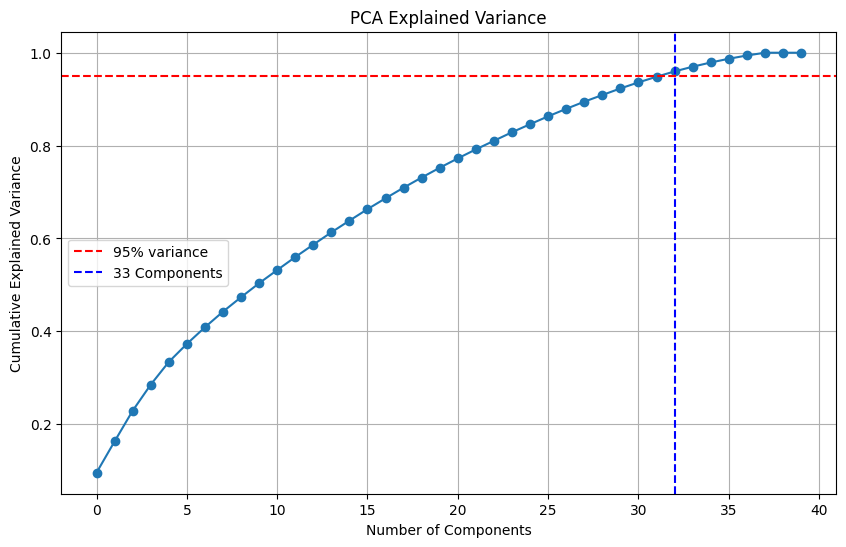

In [6]:
pca_onehot_2d, pca_onehot_features, pca_onehot_model, pca_esm_cutoff_dim = pca_reduction(X_onehot, n_components=40, labels=labels, plot_variance=True, plot_2d=False)

PCA dims to 95% variance: 88


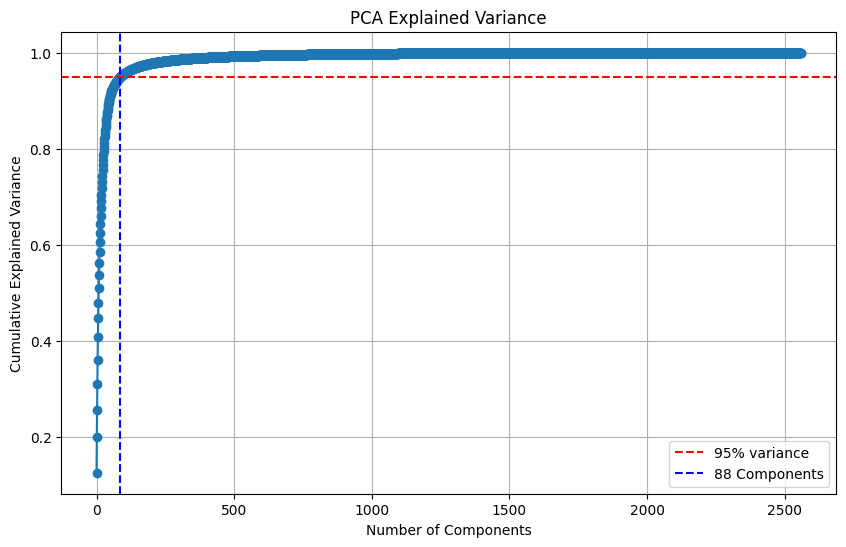

In [7]:
pca_esm_2d, pca_esm_features, pca_esm_model, pca_esm_cutoff_dim = pca_reduction(X_esm, n_components=2560, labels=labels, plot_variance=True, plot_2d=False)

In [8]:
# visulization onehot and esm PCA in 2D

PCA dims to 95% variance: 33


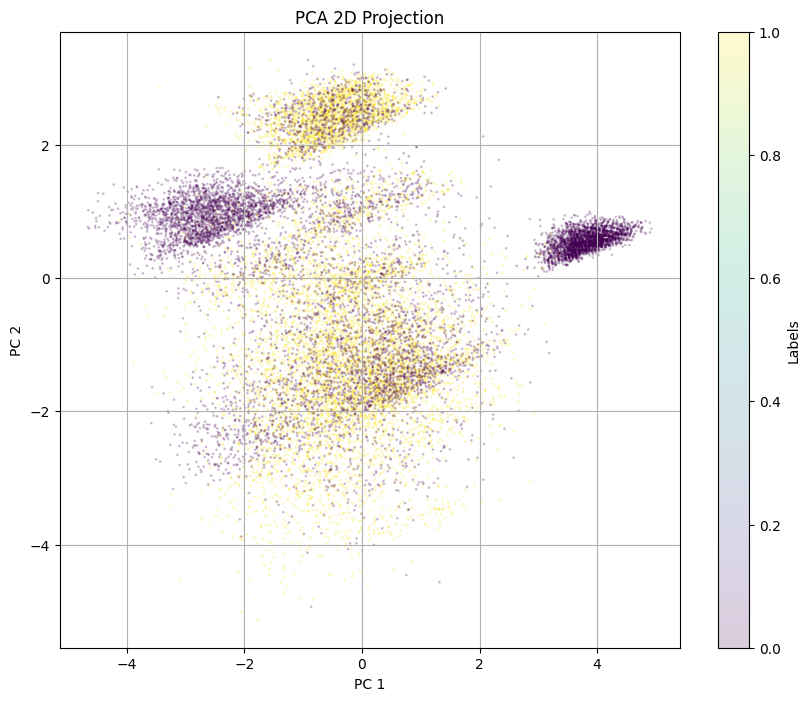

In [9]:
pca_onehot_2d, pca_onehot_features, pca_onehot_model, pca_esm_cutoff_dim = pca_reduction(X_onehot, n_components=38, labels=labels, plot_variance=False, plot_2d=True)

PCA dims to 95% variance: 88


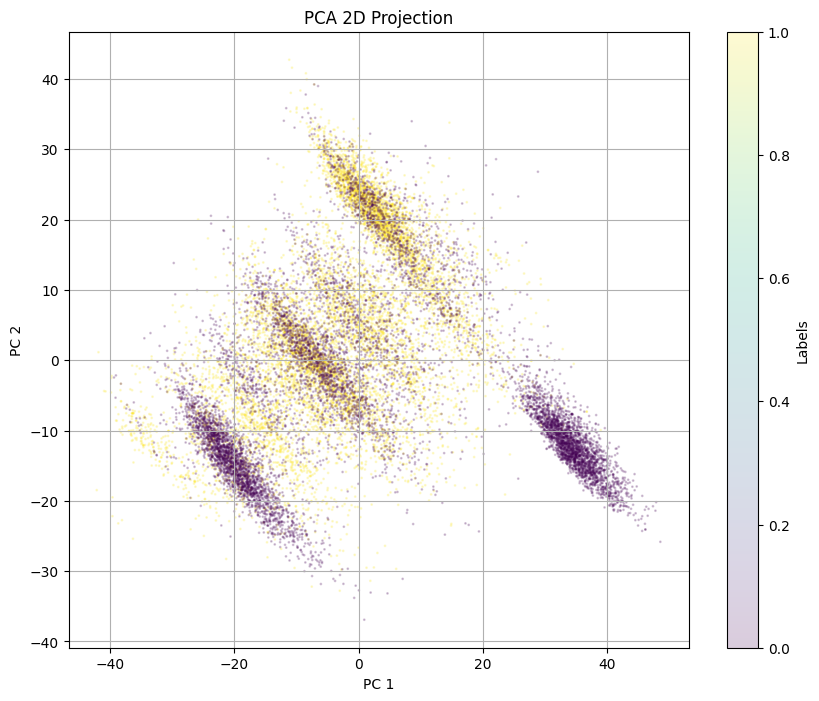

In [10]:
pca_esm_2d, pca_esm_features, pca_esm_model, pca_esm_cutoff_dim = pca_reduction(X_esm, n_components=88, labels=labels, plot_variance=False, plot_2d=True)

/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


n_components=2, score=0.0962


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


n_components=3, score=0.1102


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


...

n_components=17, score=0.0933


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


n_components=18, score=0.0948


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


n_components=19, score=0.0921


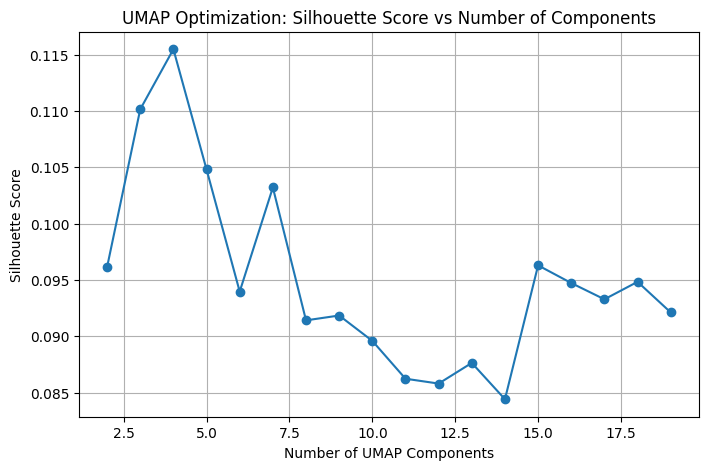

Best number of components: 4 with score 0.1155


In [11]:
# UMAP (Uniform Manifold Approximation and Projection)
# UMAP Hyperparameter Tuning
best_onehot_n_components, _ = optimize_umap_n_components(
    X_onehot, 
    label=labels, 
    n_components_range=range(2, 20))

In [12]:
best_onehot_n_components

4

/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


n_components=2, score=0.1210


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


n_components=3, score=0.1264


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


...

n_components=17, score=0.1237


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


n_components=18, score=0.1262


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


n_components=19, score=0.1274


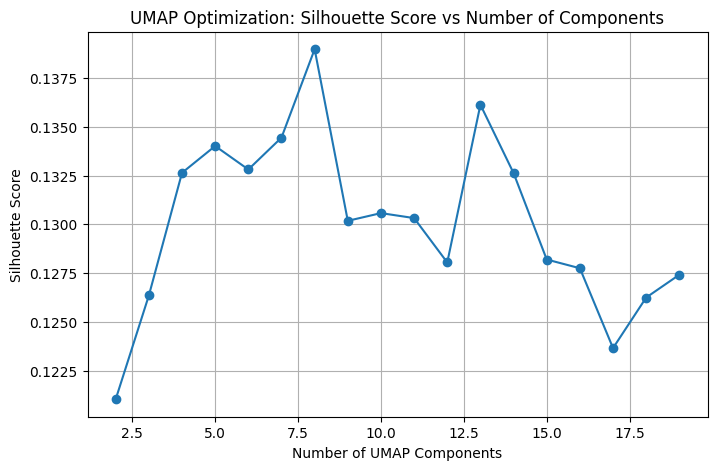

Best number of components: 8 with score 0.1390


In [13]:
best_esm_n_components, _ = optimize_umap_n_components(
    X_esm, 
    label=labels, 
    n_components_range=range(2, 20))

In [14]:
best_esm_n_components

8

Performing UMAP hyperparameter grid search...


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


n_neighbors=5, min_dist=0.1, score=0.0321


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


n_neighbors=5, min_dist=0.5, score=0.0310


...

n_neighbors=15, min_dist=0.5, score=0.0826


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


n_neighbors=30, min_dist=0.1, score=0.0731


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


n_neighbors=30, min_dist=0.5, score=0.0580
Best UMAP parameters: {'n_components': 4, 'metric': 'euclidean', 'random_state': 42, 'n_neighbors': 15, 'min_dist': 0.1}, score=0.1155


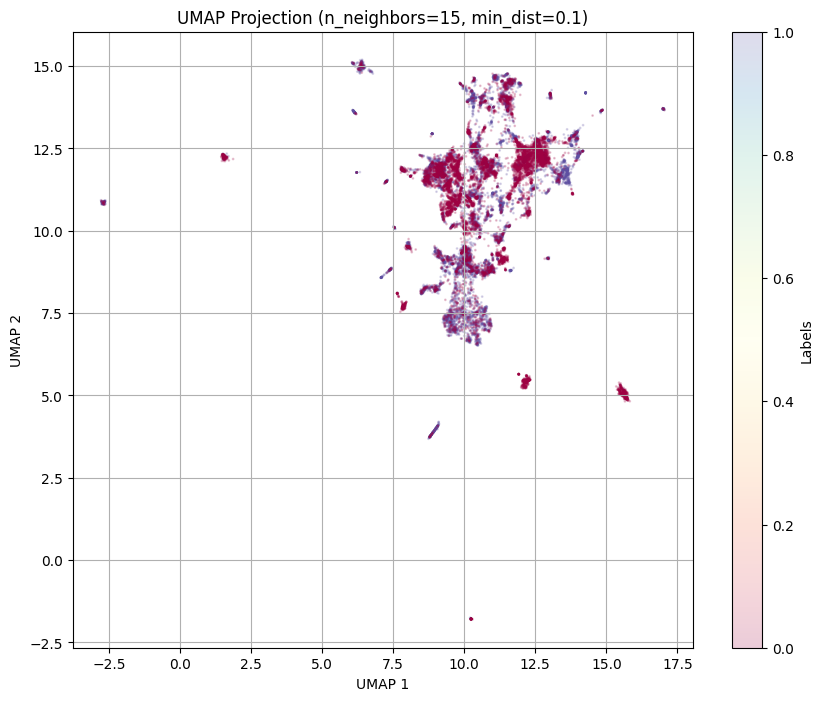

In [15]:
# UMAP (Uniform Manifold Approximation and Projection)
# UMAP Hyperparameter Tuning of onehot representation
umap_onehot_features, umap_onehot_model, onehot_params = umap_reduction(X_onehot, n_components=best_onehot_n_components, labels=labels, plot=True, grid_search=True)

Performing UMAP hyperparameter grid search...


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


n_neighbors=5, min_dist=0.1, score=0.0781


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


n_neighbors=5, min_dist=0.5, score=0.0575


...

n_neighbors=15, min_dist=0.5, score=0.1018


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


n_neighbors=30, min_dist=0.1, score=0.1390


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


n_neighbors=30, min_dist=0.5, score=0.0881
Best UMAP parameters: {'n_components': 8, 'metric': 'euclidean', 'random_state': 42, 'n_neighbors': 30, 'min_dist': 0.1}, score=0.1390


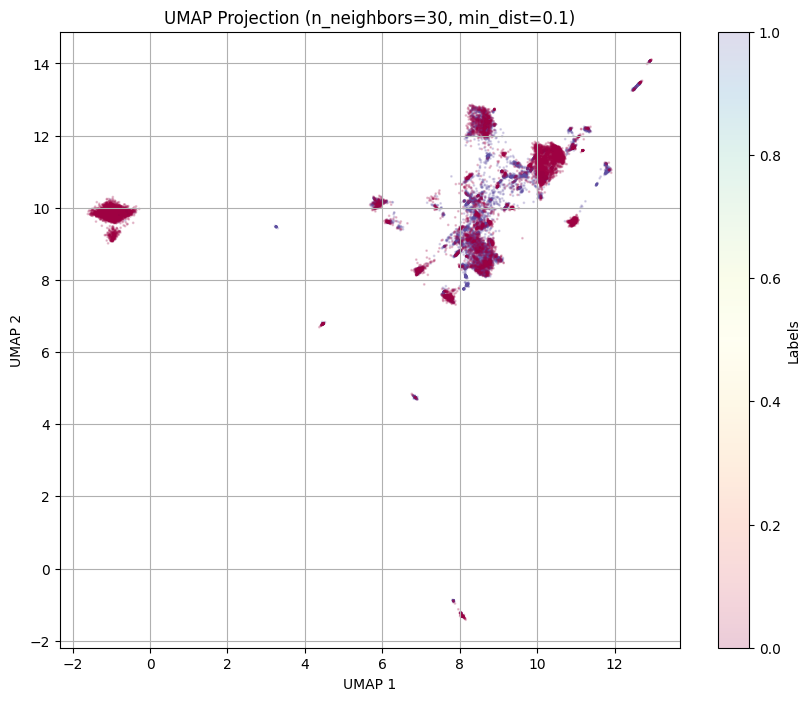

In [16]:
# UMAP Hyperparameter Tuning of esm representation
umap_esm_features, umap_esm_model, esm_params = umap_reduction(X_esm, n_components=best_esm_n_components, labels=labels, plot=True, grid_search=True)

In [17]:
umap_esm_features

array([[ 8.479863  ,  9.0813    ,  0.7626007 , ..., 11.10139   ,
         8.639603  ,  7.841522  ],
       [ 8.978944  ,  8.583033  ,  0.8698957 , ..., 11.040805  ,
         8.237754  ,  7.4808073 ],
       [ 8.530966  ,  8.884559  ,  1.2159754 , ..., 11.082908  ,
         8.7375555 ,  7.9137096 ],
       ...,
       [ 8.887545  ,  8.772157  ,  0.2508845 , ...,  6.8172154 ,
         8.439292  ,  5.687669  ],
       [ 9.99976   , 10.970601  ,  0.59480447, ...,  0.29662073,
         6.923145  ,  7.785716  ],
       [10.354699  , 10.807752  ,  1.0363768 , ...,  7.8994107 ,
         9.116496  ,  7.391342  ]], dtype=float32)

In [18]:
umap_esm_features.shape

(18864, 8)

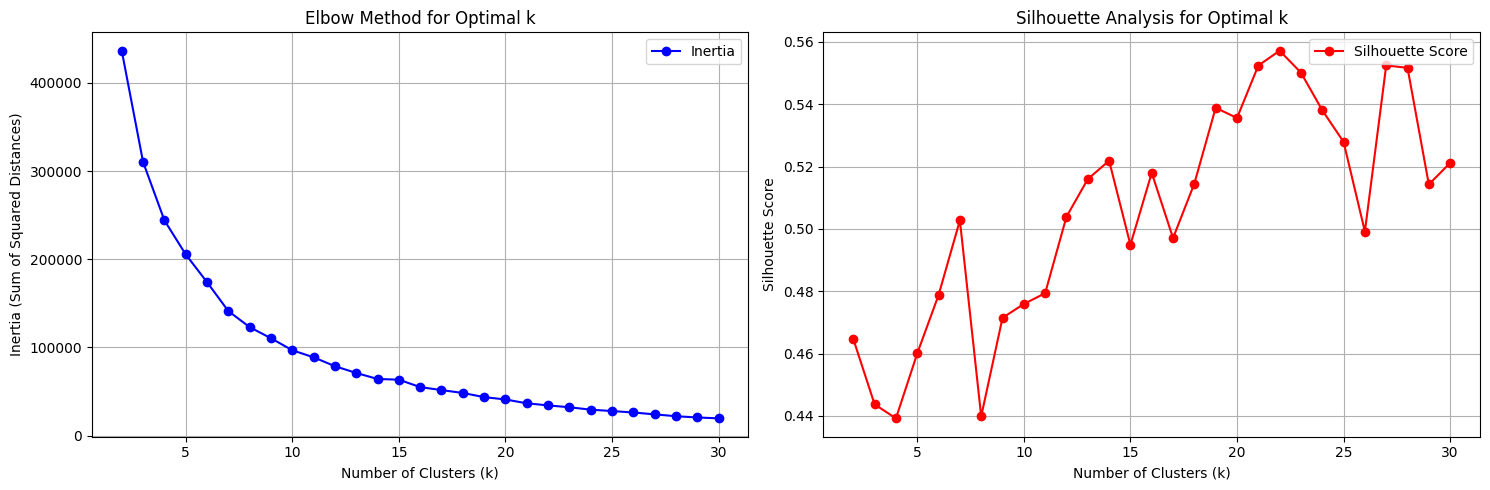

Best number of clusters by Silhouette Score: 22


In [19]:
# Hyperparameter Tuning of n of cluster for kmeans
optimal_onehot_k, _, _, _ = find_optimal_kmeans_clusters(umap_onehot_features, max_k=30)

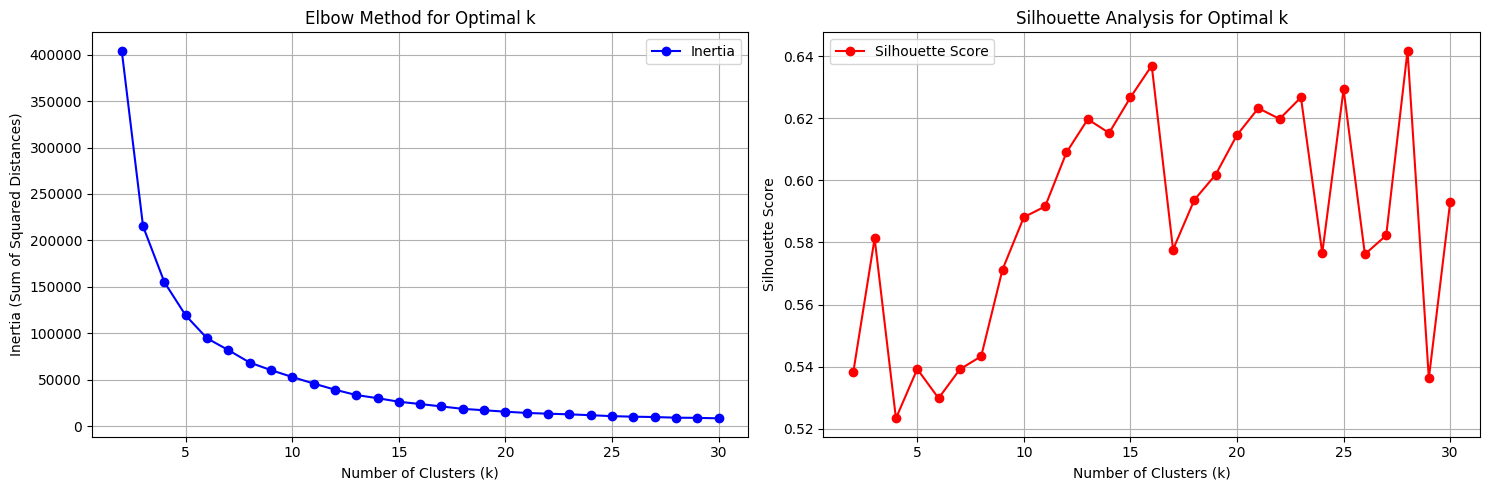

Best number of clusters by Silhouette Score: 28


In [20]:
optimal_esm_k, _, _, _ = find_optimal_kmeans_clusters(umap_esm_features, max_k=30)

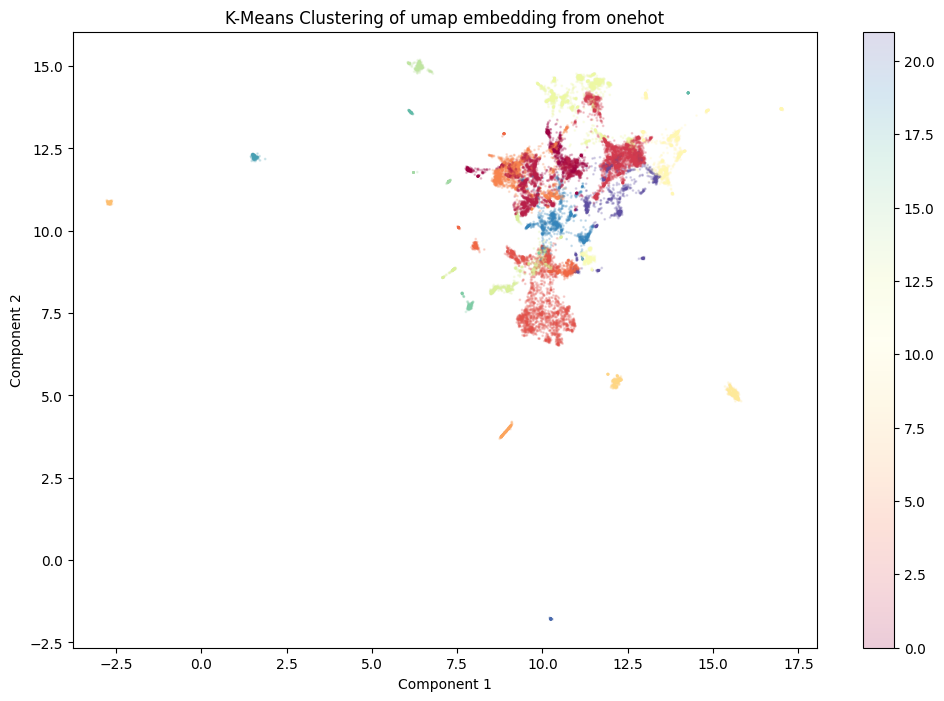

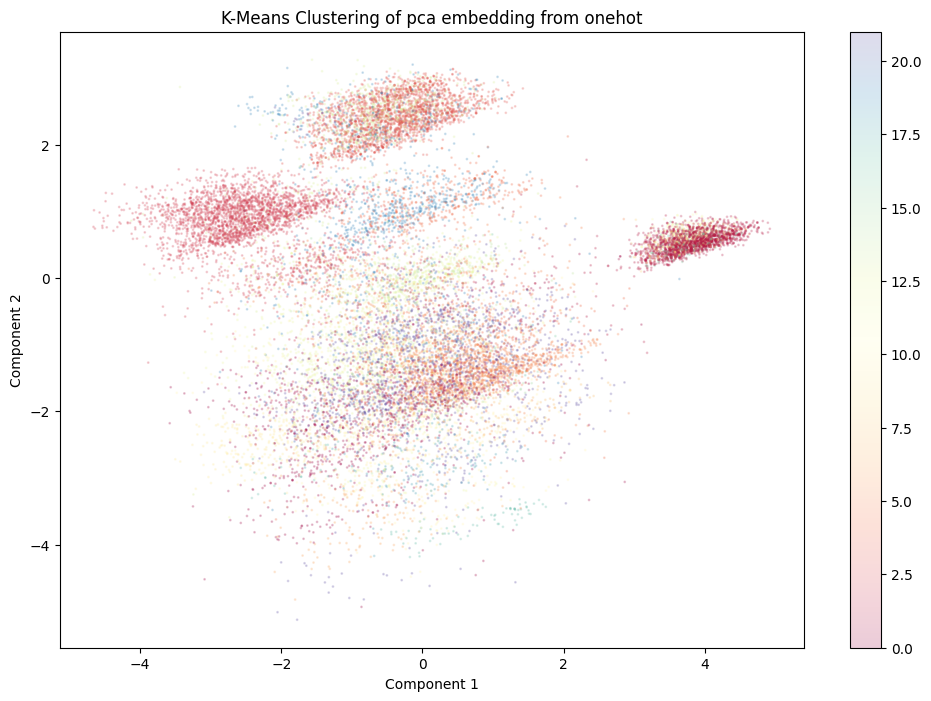

K-Means Evaluation:
Number of clusters: 22
Silhouette Score: 0.557
Cluster distribution:
  Cluster 0: 1320 points
  Cluster 1: 2078 points
  Cluster 2: 2788 points
  Cluster 3: 2259 points
  Cluster 4: 628 points
  Cluster 5: 1915 points
  Cluster 6: 214 points
  Cluster 7: 128 points
  Cluster 8: 240 points
  Cluster 9: 297 points
  Cluster 10: 973 points
  Cluster 11: 264 points
  Cluster 12: 1559 points
  Cluster 13: 892 points
  Cluster 14: 246 points
  Cluster 15: 96 points
  Cluster 16: 170 points
  Cluster 17: 103 points
  Cluster 18: 154 points
  Cluster 19: 1083 points
  Cluster 20: 47 points
  Cluster 21: 1410 points


(22, 0.5571531)

In [21]:
# Find optimal K and cluster
kmeans = KMeans(n_clusters=optimal_onehot_k, random_state=42, n_init=10)
kmeans_onehot_labels = kmeans.fit_predict(umap_onehot_features)  # Use PCA-reduced features

# # Visualization and Evaluation
# Visualize different clustering results
visualize_clusters(umap_onehot_features, kmeans_onehot_labels, "K-Means Clustering of umap embedding from onehot")

# Visualize different clustering results
visualize_clusters(pca_onehot_2d, kmeans_onehot_labels, "K-Means Clustering of pca embedding from onehot")

# Evaluate clustering
print("K-Means Evaluation:")
evaluate_clustering(umap_onehot_features, kmeans_onehot_labels)

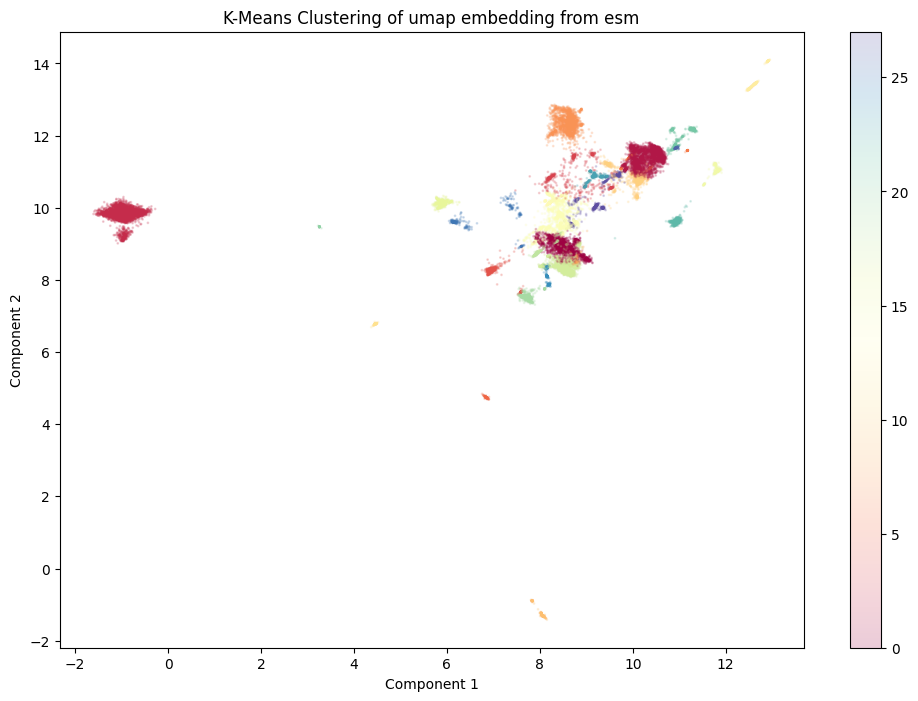

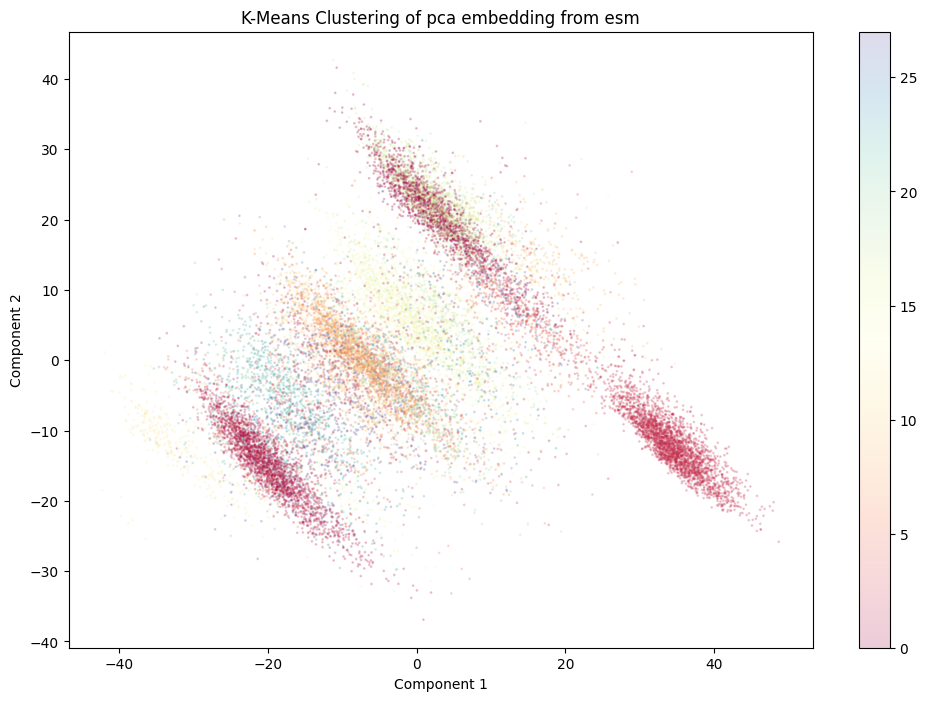

K-Means Evaluation:
Number of clusters: 22
Silhouette Score: 0.163
Cluster distribution:
  Cluster 0: 1320 points
  Cluster 1: 2078 points
  Cluster 2: 2788 points
  Cluster 3: 2259 points
  Cluster 4: 628 points
  Cluster 5: 1915 points
  Cluster 6: 214 points
  Cluster 7: 128 points
  Cluster 8: 240 points
  Cluster 9: 297 points
  Cluster 10: 973 points
  Cluster 11: 264 points
  Cluster 12: 1559 points
  Cluster 13: 892 points
  Cluster 14: 246 points
  Cluster 15: 96 points
  Cluster 16: 170 points
  Cluster 17: 103 points
  Cluster 18: 154 points
  Cluster 19: 1083 points
  Cluster 20: 47 points
  Cluster 21: 1410 points


(22, 0.16277549)

In [22]:
# Find optimal K and cluster
kmeans = KMeans(n_clusters=optimal_esm_k, random_state=42, n_init=10)
kmeans_esm_labels = kmeans.fit_predict(umap_esm_features)  # Use PCA-reduced features

# # Visualization and Evaluation
# Visualize different clustering results
visualize_clusters(umap_esm_features, kmeans_esm_labels, "K-Means Clustering of umap embedding from esm")

# Visualize different clustering results
visualize_clusters(pca_esm_2d, kmeans_esm_labels, "K-Means Clustering of pca embedding from esm")

# Evaluate clustering
print("K-Means Evaluation:")
evaluate_clustering(umap_esm_features, kmeans_onehot_labels)

In [23]:
# those results show that using umap embedding from esm provide best representation of the data as feature for downstream applicaton

In [24]:
esm_params

{'n_components': 8,
 'metric': 'euclidean',
 'random_state': 42,
 'n_neighbors': 30,
 'min_dist': 0.1}

In [25]:
n_components = 8
metric = 'euclidean'
min_dist = 0.1
best_n_clusters = 22
best_n_neighbors = 30

Sensitivity to UMAP n_neighbors:


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


  n_neighbors=15: Silhouette Score = 0.14


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


  n_neighbors=30: Silhouette Score = 0.14


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


  n_neighbors=45: Silhouette Score = 0.13

Sensitivity to K-Means n_clusters:


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


  n_clusters=12: Silhouette Score = 0.14
  n_clusters=22: Silhouette Score = 0.14
  n_clusters=32: Silhouette Score = 0.14


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


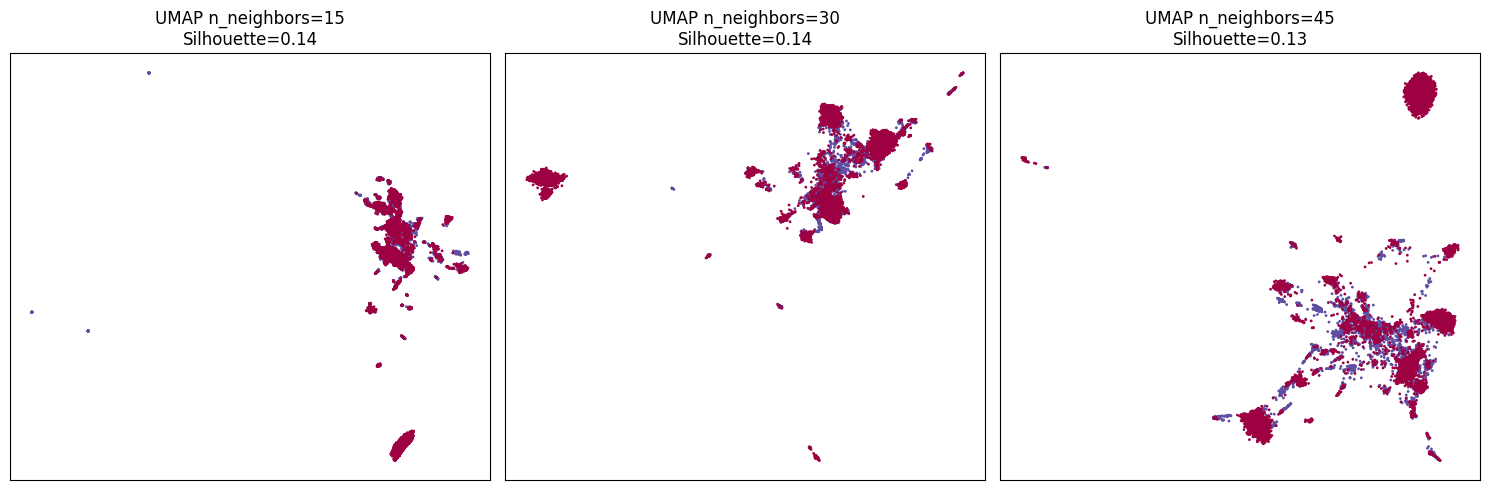

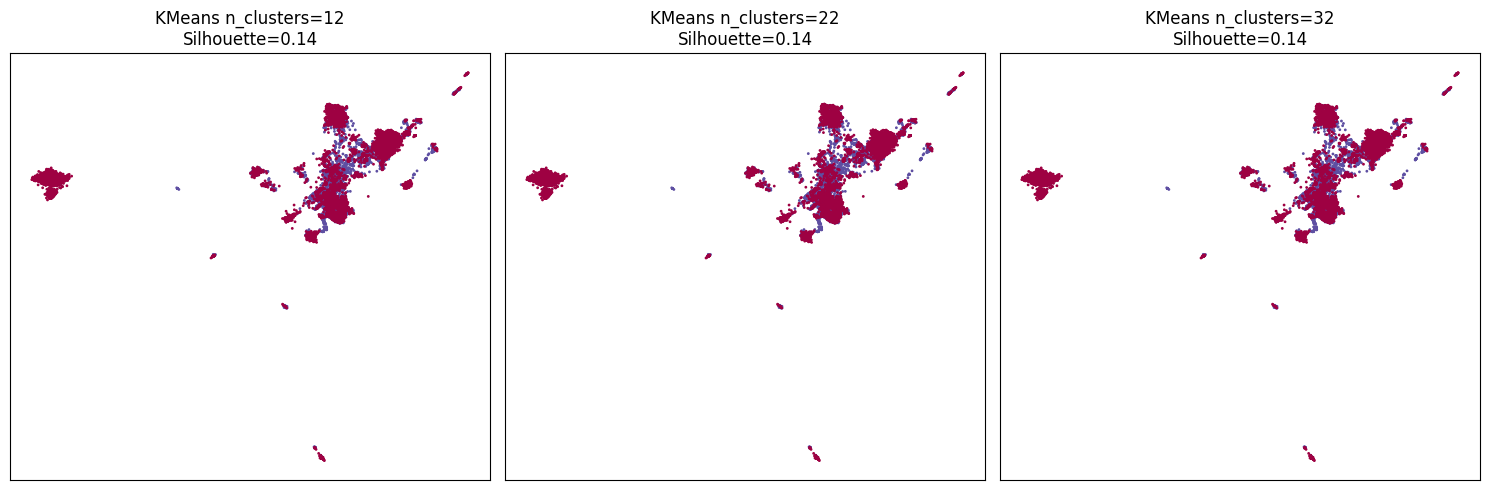

In [26]:
sensitivity_analysis(X_esm, labels=labels)

Sensitivity to UMAP n_neighbors:


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


  n_neighbors=15: Silhouette Score = 0.62


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


  n_neighbors=30: Silhouette Score = 0.62


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


  n_neighbors=45: Silhouette Score = 0.58

Sensitivity to K-Means n_clusters:


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


  n_clusters=12: Silhouette Score = 0.61
  n_clusters=22: Silhouette Score = 0.62
  n_clusters=32: Silhouette Score = 0.49


/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


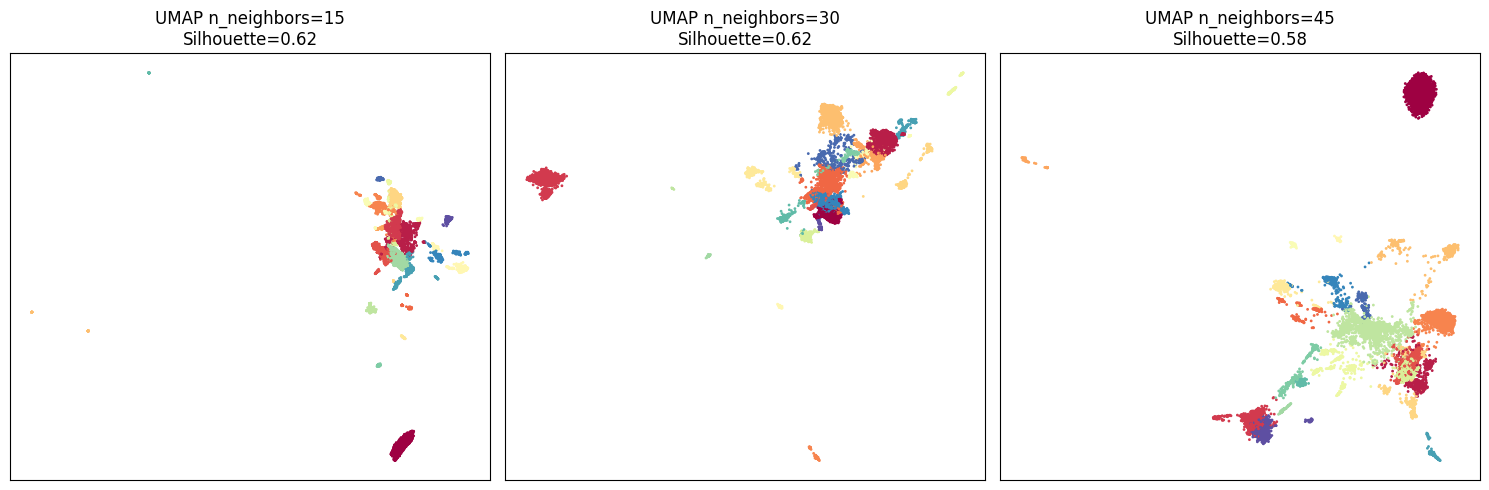

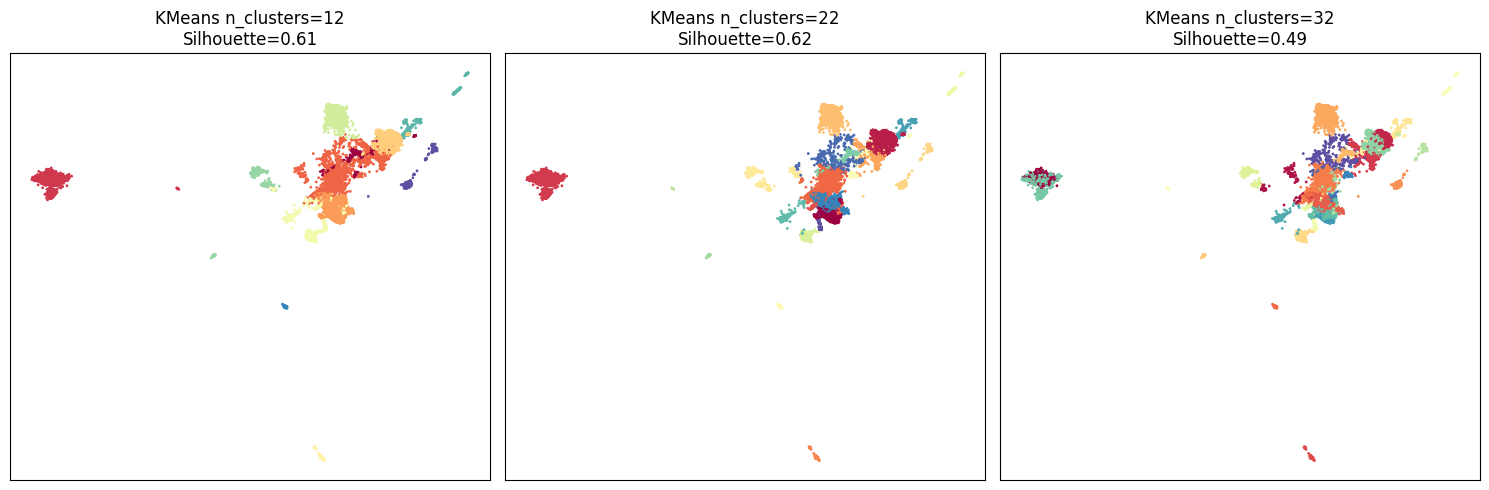

In [27]:
sensitivity_analysis(X_esm)

In [28]:
n_components = 8
metric = 'euclidean'
min_dist = 0.1
best_n_clusters = 22
best_n_neighbors = 30
n_pca_components = 88

In [29]:
# training the model and extract pca,umap and kmeans features
unsupervised_features_df, pca_model, umap_model, kmeans_model = create_unsupervised_features(X_esm, n_pca_components=n_pca_components, n_umap_components=n_components, embedding_type="", training=True)

/Users/newuser/anaconda3/envs/PerturbNet/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [30]:
unsupervised_features_df.head(2)

,pca_feature_dim1,pca_feature_dim2,pca_feature_dim3,pca_feature_dim4,pca_feature_dim5,pca_feature_dim6,pca_feature_dim7,pca_feature_dim8,pca_feature_dim9,pca_feature_dim10,...,pca_feature_dim88,umap_feature_dim1,umap_feature_dim2,umap_feature_dim3,umap_feature_dim4,umap_feature_dim5,umap_feature_dim6,umap_feature_dim7,umap_feature_dim8,kmeans_cluster
0,-0.448583,27.382933,6.704241,2.735436,-5.416729,-9.196397,0.512581,-5.977508,-3.063737,3.976454,...,0.439741,8.479863,9.081300,0.762601,-0.482129,11.997458,11.101390,8.639603,7.841522,18
1,13.344002,8.632728,-27.694826,-4.946911,-9.706250,-11.600757,-4.462359,2.934498,-14.646651,-4.060844,...,0.265729,8.978944,8.583033,0.869896,-0.715207,12.353375,11.040805,8.237754,7.480807,18


In [31]:
unsupervised_features_df.columns

Index(['pca_feature_dim1', 'pca_feature_dim2', 'pca_feature_dim3',
       'pca_feature_dim4', 'pca_feature_dim5', 'pca_feature_dim6',
       'pca_feature_dim7', 'pca_feature_dim8', 'pca_feature_dim9',
       'pca_feature_dim10', 'pca_feature_dim11', 'pca_feature_dim12',
       'pca_feature_dim13', 'pca_feature_dim14', 'pca_feature_dim15',
       'pca_feature_dim16', 'pca_feature_dim17', 'pca_feature_dim18',
       'pca_feature_dim19', 'pca_feature_dim20', 'pca_feature_dim21',
       'pca_feature_dim22', 'pca_feature_dim23', 'pca_feature_dim24',
       'pca_feature_dim25', 'pca_feature_dim26', 'pca_feature_dim27',
       'pca_feature_dim28', 'pca_feature_dim29', 'pca_feature_dim30',
       'pca_feature_dim31', 'pca_feature_dim32', 'pca_feature_dim33',
       'pca_feature_dim34', 'pca_feature_dim35', 'pca_feature_dim36',
       'pca_feature_dim37', 'pca_feature_dim38', 'pca_feature_dim39',
       'pca_feature_dim40', 'pca_feature_dim41', 'pca_feature_dim42',
       'pca_feature_dim43', '

In [32]:
unsupervised_features_df["kmeans_cluster"].value_counts()

kmeans_cluster
1     2742
7     2494
10    2092
18    1851
4     1582
11    1500
6     1378
13     700
2      643
17     610
14     531
19     484
5      482
12     461
16     364
20     299
8      219
9      131
15     126
3       96
0       48
21      31
Name: count, dtype: int64

In [33]:
X = pd.read_csv("Datasets/VDJdb_PosNeg_corrected_onehot_esm.csv")
final_dataset = pd.concat([X, unsupervised_features_df], axis=1)
final_dataset = final_dataset.loc[:, ~final_dataset.columns.str.contains('^Unnamed')]

In [34]:
final_dataset.head(2)

,complex.id,gene,cdr3,v.segm,j.segm,species,mhc.a,mhc.b,mhc.class,antigen.epitope,...,pca_feature_dim88,umap_feature_dim1,umap_feature_dim2,umap_feature_dim3,umap_feature_dim4,umap_feature_dim5,umap_feature_dim6,umap_feature_dim7,umap_feature_dim8,kmeans_cluster
0,0,TRB,CASSIVGGNEQFF,TRBV19*01,TRBJ2-1*01,HomoSapiens,HLA-A*02:01,B2M,MHCI,GILGFVFTL,...,0.439741,8.479863,9.081300,0.762601,-0.482129,11.997458,11.101390,8.639603,7.841522,18
1,0,TRB,CASSMRSTGELFF,TRBV19*01,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,B2M,MHCI,GILGFVFTL,...,0.265729,8.978944,8.583033,0.869896,-0.715207,12.353375,11.040805,8.237754,7.480807,18


In [35]:
final_dataset.to_csv("Datasets/VDJdb_PosNeg_corrected_onehot_pca_umap_kmeans.csv")

In [36]:
final_dataset.columns

Index(['complex.id', 'gene', 'cdr3', 'v.segm', 'j.segm', 'species', 'mhc.a',
       'mhc.b', 'mhc.class', 'antigen.epitope',
       ...
       'pca_feature_dim88', 'umap_feature_dim1', 'umap_feature_dim2',
       'umap_feature_dim3', 'umap_feature_dim4', 'umap_feature_dim5',
       'umap_feature_dim6', 'umap_feature_dim7', 'umap_feature_dim8',
       'kmeans_cluster'],
      dtype='object', length=2717)

In [37]:
# Filter columns starting with 'cdr3' or 'umap'
selected_columns = [col for col in final_dataset.columns if col.startswith('cdr3') or col.startswith('umap') or col.startswith('epitope') or col.startswith('pca') or col.startswith('kmeans') ]

In [38]:
len(selected_columns)

2698

In [39]:
selected_columns = [col for col in final_dataset.columns if col.startswith('umap') or col.startswith('pca') or col.startswith('kmeans') ]
selected_columns

['pca_feature_dim1',
 'pca_feature_dim2',
 'pca_feature_dim3',
 'pca_feature_dim4',
 'pca_feature_dim5',
 'pca_feature_dim6',
 'pca_feature_dim7',
 'pca_feature_dim8',
 'pca_feature_dim9',
 'pca_feature_dim10',
 'pca_feature_dim11',
 'pca_feature_dim12',
 'pca_feature_dim13',
 'pca_feature_dim14',
 'pca_feature_dim15',
 'pca_feature_dim16',
 'pca_feature_dim17',
 'pca_feature_dim18',
 'pca_feature_dim19',
 'pca_feature_dim20',
 'pca_feature_dim21',
 'pca_feature_dim22',
 'pca_feature_dim23',
 'pca_feature_dim24',
 'pca_feature_dim25',
 'pca_feature_dim26',
 'pca_feature_dim27',
 'pca_feature_dim28',
 'pca_feature_dim29',
 'pca_feature_dim30',
 'pca_feature_dim31',
 'pca_feature_dim32',
 'pca_feature_dim33',
 'pca_feature_dim34',
 'pca_feature_dim35',
 'pca_feature_dim36',
 'pca_feature_dim37',
 'pca_feature_dim38',
 'pca_feature_dim39',
 'pca_feature_dim40',
 'pca_feature_dim41',
 'pca_feature_dim42',
 'pca_feature_dim43',
 'pca_feature_dim44',
 'pca_feature_dim45',
 'pca_feature_dim46

In [40]:

# feature_for_supervised
embedding_feature = []

unsupervised_feature = ['pca_feature_dim1', 'pca_feature_dim2', 'pca_feature_dim3', 'pca_feature_dim4', 'pca_feature_dim5', 'pca_feature_dim6', 'pca_feature_dim7', 'pca_feature_dim8', 'pca_feature_dim9', 'pca_feature_dim10', 'pca_feature_dim11', 'pca_feature_dim12', 'pca_feature_dim13', 'pca_feature_dim14', 'pca_feature_dim15', 'pca_feature_dim16', 'pca_feature_dim17', 'pca_feature_dim18', 'pca_feature_dim19', 'pca_feature_dim20', 'pca_feature_dim21', 'pca_feature_dim22', 'pca_feature_dim23', 'pca_feature_dim24', 'pca_feature_dim25', 'pca_feature_dim26', 'pca_feature_dim27', 'pca_feature_dim28', 'pca_feature_dim29', 'pca_feature_dim30', 'pca_feature_dim31', 'pca_feature_dim32', 'pca_feature_dim33', 'pca_feature_dim34', 'pca_feature_dim35', 'umap_feature_dim1', 'umap_feature_dim2', 'umap_feature_dim3', 'umap_feature_dim4', 'umap_feature_dim5', 'umap_feature_dim6', 'umap_feature_dim7', 'umap_feature_dim8', 'umap_feature_dim9', 'umap_feature_dim10', 'kmeans_cluster']


# if you think there are too many features here
recommend_features =  ['umap_feature_dim1',
 'umap_feature_dim2',
 'umap_feature_dim3',
 'umap_feature_dim4',
 'umap_feature_dim5',
 'umap_feature_dim6',
 'umap_feature_dim7',
 'umap_feature_dim8',
 'kmeans_cluster']